In [1]:
pip install medmnist torch torchvision scikit-learn tqdm matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Running execution pipeline on Device: cuda

 STARTING PIPELINE FOR DATASET: RetinaMNIST (5 Classes)


100%|██████████| 3.29M/3.29M [00:05<00:00, 596kB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]



--- Training RESNET on RETINAMNIST ---


...

100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]



--- Training DENSENET on RETINAMNIST ---


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]


--- Training MOBILEVIT on RETINAMNIST ---



================ FINAL METRICS FOR RETINAMNIST ================

--- TRAIN SET RESULTS ---
Model           | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------
RESNET          | 0.9858     | 0.9860     | 0.9858     | 0.9858    
EFFICIENTNET    | 1.0000     | 1.0000     | 1.0000     | 1.0000    
DENSENET        | 0.9967     | 0.9968     | 0.9967     | 0.9967    
MOBILEVIT       | 1.0000     | 1.0000     | 1.0000     | 1.0000    

--- VALIDATION SET RESULTS ---
Model           | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------
RESNET          | 0.5000     | 0.5134     | 0.5000     | 0.5045    
EFFICIENTNET    | 0.5494     | 0.5719     | 0.5494     | 0.5579    
DENSENET        | 0.5247     | 0.5294     | 0.5247     | 0.5268    
MOBILEVIT       | 0.5062     | 0.5186     | 0.5062     | 0.5105    

--- TEST SET RESULTS ---
Model           | Accuracy   | Precisi

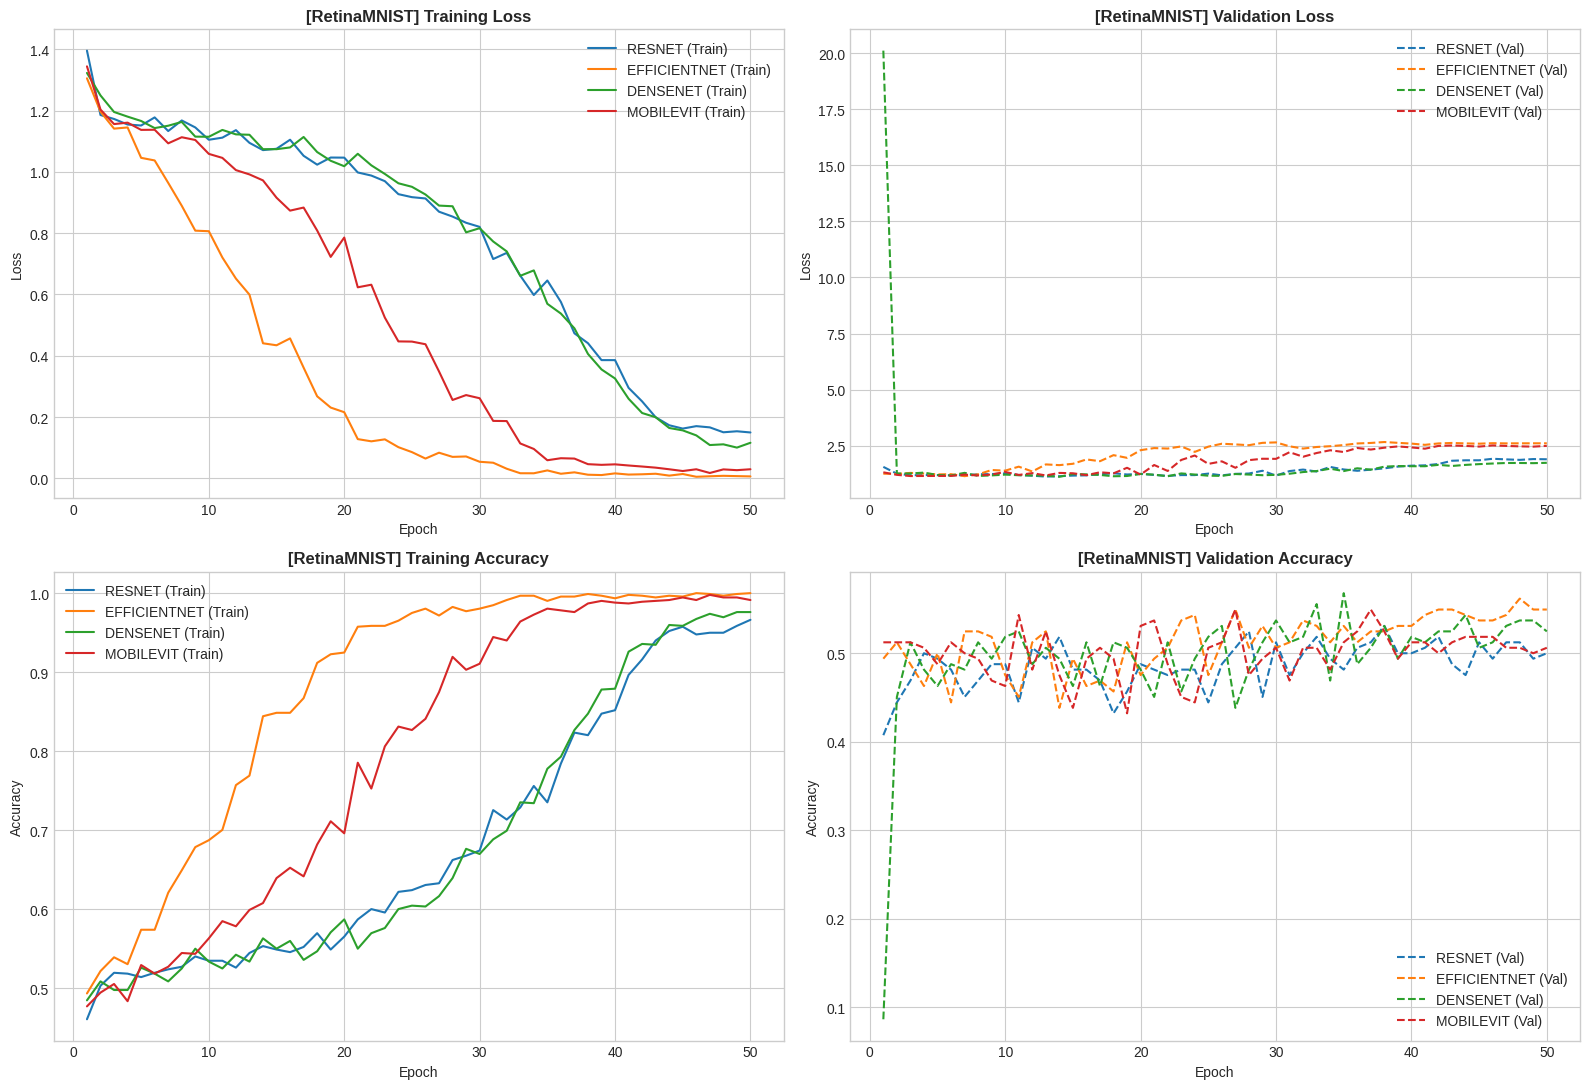

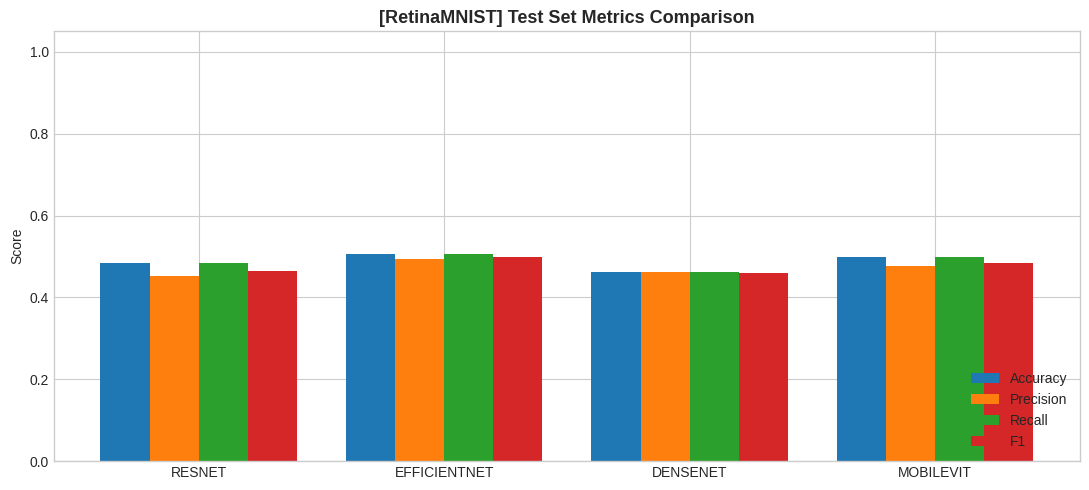


 STARTING PIPELINE FOR DATASET: BloodMNIST (8 Classes)


100%|██████████| 35.5M/35.5M [00:48<00:00, 736kB/s]



--- Training RESNET on BLOODMNIST ---



--- Training EFFICIENTNET on BLOODMNIST ---



--- Training DENSENET on BLOODMNIST ---



--- Training MOBILEVIT on BLOODMNIST ---



================ FINAL METRICS FOR BLOODMNIST ================

--- TRAIN SET RESULTS ---
Model           | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------
RESNET          | 1.0000     | 1.0000     | 1.0000     | 1.0000    
EFFICIENTNET    | 1.0000     | 1.0000     | 1.0000     | 1.0000    
DENSENET        | 1.0000     | 1.0000     | 1.0000     | 1.0000    
MOBILEVIT       | 1.0000     | 1.0000     | 1.0000     | 1.0000    

--- VALIDATION SET RESULTS ---
Model           | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------
RESNET          | 0.9788     | 0.9789     | 0.9788     | 0.9788    
EFFICIENTNET    | 0.9810     | 0.9814     | 0.9810     | 0.9811    
DENSENET        | 0.9866     | 0.9867     | 0.9866     | 0.9866    
MOBILEVIT       | 0.9816     | 0.9822     | 0.9816     | 0.9817    

--- TEST SET RESULTS ---
Model           | Accuracy   | Precisio

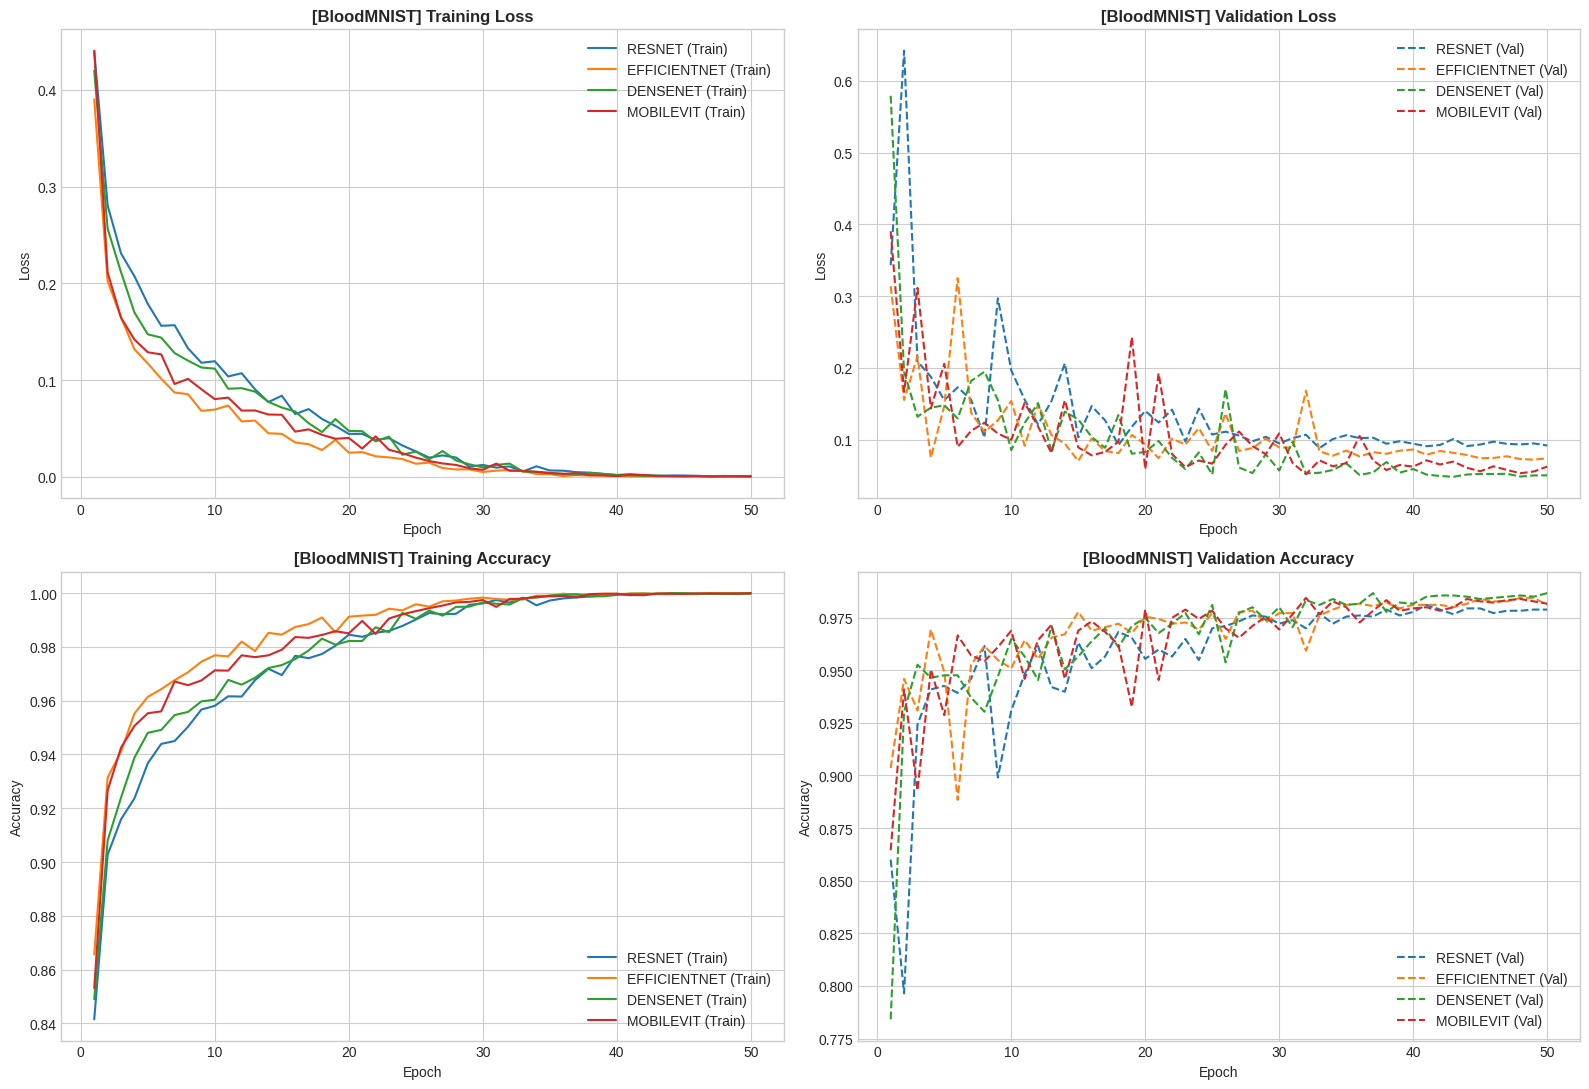

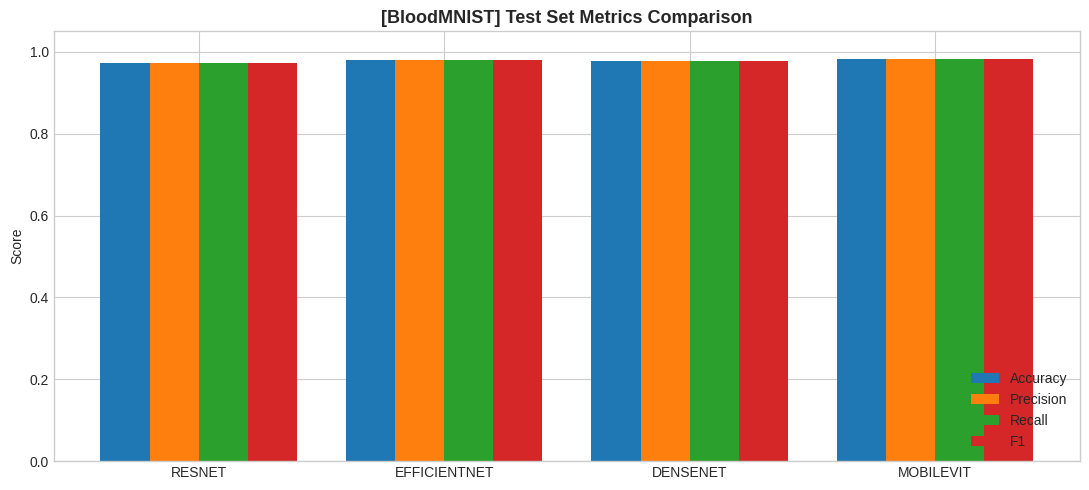

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

# Ensure timm is installed for MobileViT
try:
    import timm
except ImportError:
    os.system("pip install timm")
    import timm

import medmnist
from medmnist import INFO

# ==========================================
# 1. Reproducibility & Global Configuration
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

# Target Datasets & Architectures
DATASET_KEYS = ['retinamnist', 'bloodmnist']
ARCHITECTURES = ['resnet', 'efficientnet', 'densenet', 'mobilevit']

print(f"Running execution pipeline on Device: {DEVICE}")

# ==========================================
# 2. Universal Data Transforms & Dataset Wrapper
# ==========================================
# Grayscale-to-RGB conversion enables processing 1-channel images alongside 3-channel datasets
data_transforms = {
    'train': transforms.Compose([
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'eval': transforms.Compose([
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

class MedMNISTWrapper(Dataset):
    """Wrapper to safely apply transforms to PIL images from MedMNIST subsets."""
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, target = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, target

# ==========================================
# 3. Dynamic Model Builder (timm for MobileViT)
# ==========================================
def build_model(architecture_name, num_classes):
    if architecture_name == 'resnet':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif architecture_name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif architecture_name == 'densenet':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif architecture_name == 'mobilevit':
        model = timm.create_model('mobilevit_s', pretrained=True, num_classes=num_classes)

    else:
        raise ValueError(f"Unsupported model architecture: {architecture_name}")

    return model.to(DEVICE)

# ==========================================
# 4. Training & Metric Evaluation Functions
# ==========================================
def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

def evaluate_loader(model, dataloader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.view(-1).long()  # Safe flattening regardless of batch size

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    return compute_metrics(np.array(all_targets), np.array(all_preds))

def train_model(model_name, dataset_name, train_loader, val_loader, num_classes, epochs=EPOCHS):
    model = build_model(model_name, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None

    print(f"\n--- Training {model_name.upper()} on {dataset_name.upper()} ---")
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        train_bar = tqdm(train_loader, desc=f"[{dataset_name}|{model_name}] Epoch {epoch+1:02d}/{epochs}", leave=False)

        for images, labels in train_bar:
            images = images.to(DEVICE)
            labels = labels.view(-1).long().to(DEVICE)  # Safe flattening

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total

        # Validation Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.view(-1).long().to(DEVICE)  # Safe flattening

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels).item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = model.state_dict().copy()

    if best_weights:
        model.load_state_dict(best_weights)

    return model, history

# ==========================================
# 5. Visualization Helper per Dataset
# ==========================================
def plot_dataset_results(dataset_name, histories, test_results):
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    # 1. Training & Validation Loss
    for arch in ARCHITECTURES:
        axes[0, 0].plot(range(1, EPOCHS + 1), histories[arch]['train_loss'], label=f"{arch.upper()} (Train)")
        axes[0, 1].plot(range(1, EPOCHS + 1), histories[arch]['val_loss'], linestyle='--', label=f"{arch.upper()} (Val)")

    axes[0, 0].set_title(f"[{dataset_name}] Training Loss", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

    axes[0, 1].set_title(f"[{dataset_name}] Validation Loss", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend()

    # 2. Training & Validation Accuracy
    for arch in ARCHITECTURES:
        axes[1, 0].plot(range(1, EPOCHS + 1), histories[arch]['train_acc'], label=f"{arch.upper()} (Train)")
        axes[1, 1].plot(range(1, EPOCHS + 1), histories[arch]['val_acc'], linestyle='--', label=f"{arch.upper()} (Val)")

    axes[1, 0].set_title(f"[{dataset_name}] Training Accuracy", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Accuracy"); axes[1, 0].legend()

    axes[1, 1].set_title(f"[{dataset_name}] Validation Accuracy", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy"); axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    # 3. Test Metrics Bar Chart
    fig, ax = plt.subplots(figsize=(11, 5))
    model_names = [arch.upper() for arch in ARCHITECTURES]
    metric_keys = ['accuracy', 'precision', 'recall', 'f1']
    x = np.arange(len(model_names))
    width = 0.2

    for i, metric in enumerate(metric_keys):
        values = [test_results[arch][metric] for arch in ARCHITECTURES]
        ax.bar(x + i * width, values, width, label=metric.capitalize())

    ax.set_title(f"[{dataset_name}] Test Set Metrics Comparison", fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names)
    ax.set_ylabel("Score")
    ax.set_ylim([0, 1.05])
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Main Execution Pipeline
# ==========================================
for key in DATASET_KEYS:
    info = INFO[key]
    data_class_name = info['python_class']
    num_classes = len(info['label'])
    DataClass = getattr(medmnist, data_class_name)

    print(f"\n========================================================")
    print(f" STARTING PIPELINE FOR DATASET: {data_class_name} ({num_classes} Classes)")
    print(f"========================================================")

    # Download / Load Data
    raw_train_data = DataClass(split='train', download=True)
    raw_test_data = DataClass(split='test', download=True)

    # Perform 85% / 15% Train/Validation Split
    val_ratio = 0.15
    val_size = int(len(raw_train_data) * val_ratio)
    train_size = len(raw_train_data) - val_size

    raw_train_subset, raw_val_subset = random_split(
        raw_train_data, [train_size, val_size], generator=torch.Generator().manual_seed(42)
    )

    # Wrap Datasets with Standardized Transforms
    train_dataset = MedMNISTWrapper(raw_train_subset, transform=data_transforms['train'])
    val_dataset = MedMNISTWrapper(raw_val_subset, transform=data_transforms['eval'])
    test_dataset = MedMNISTWrapper(raw_test_data, transform=data_transforms['eval'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    histories = {}
    test_results = {}
    val_results = {}
    train_results = {}

    # Train and Evaluate Models
    for arch in ARCHITECTURES:
        model, history = train_model(arch, data_class_name, train_loader, val_loader, num_classes, epochs=EPOCHS)
        histories[arch] = history

        # Evaluation Across Splits
        train_results[arch] = evaluate_loader(model, train_loader)
        val_results[arch] = evaluate_loader(model, val_loader)
        test_results[arch] = evaluate_loader(model, test_loader)

    # Print Metric Tables per Dataset
    print(f"\n================ FINAL METRICS FOR {data_class_name.upper()} ================")
    for split_name, results_dict in [("TRAIN", train_results), ("VALIDATION", val_results), ("TEST", test_results)]:
        print(f"\n--- {split_name} SET RESULTS ---")
        print(f"{'Model':<15} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
        print("-" * 65)
        for arch in ARCHITECTURES:
            m = results_dict[arch]
            print(f"{arch.upper():<15} | {m['accuracy']:<10.4f} | {m['precision']:<10.4f} | {m['recall']:<10.4f} | {m['f1']:<10.4f}")

    # Plot Visual Analytics
    plot_dataset_results(data_class_name, histories, test_results)